# Retail Sales — Data Cleaning, Analysis & Visualization

**DevRise Internship Program — Batch 1 (2026) | AI & ML | Task 1**

**Objective:** Perform data cleaning, analysis, and visualization on a raw retail sales dataset,
handle missing records and anomalies, compute descriptive statistics, and generate
expressive visualizations to communicate business trends.

**Dataset:** `raw_retail_sales.csv` — a retail order-level dataset (3,040 raw records) containing
order date, region, product category, sales channel, payment mode, quantity, unit price,
discount, customer demographics, and total sales. The raw file mirrors common real-world
data issues: missing values, duplicate rows, inconsistent text casing, mixed data types,
invalid (negative) quantities, and price outliers.

**Tech stack:** `pandas`, `numpy`, `matplotlib`, `seaborn`


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.autolayout"] = True

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

import os
os.makedirs("../visuals", exist_ok=True)


## 2. Load the Raw Dataset

In [2]:
df_raw = pd.read_csv("../data/raw_retail_sales.csv")
print("Shape:", df_raw.shape)
df_raw.head(10)


Shape: (3040, 12)


,OrderID,OrderDate,Region,Category,SalesChannel,PaymentMode,Quantity,UnitPrice,DiscountPercent,CustomerAge,CustomerRating,TotalSales
0,102901,2025-08-08,West,Home & Kitchen,In-Store,UPI,10.0,62.65,20.0,29.0,3.0,501.20
1,101422,2025-03-06,north,Beauty,Online,UPI,10.0,56.94,0.0,22.0,4.7,569.40
2,102731,2025-01-16,North,Clothing,Online,Debit Card,7.0,41.88,0.0,45.0,2.3,293.16
3,100603,2024-04-08,Central,Clothing,Online,Debit Card,3.0,40.18,20.0,32.0,1.9,96.43
4,100562,2024-12-26,east,SPORTS,Online,Debit Card,9.0,67.04,0.0,51.0,3.4,603.36
5,102265,2024-03-10,West,Home & Kitchen,In-Store,UPI,3.0,146.29,15.0,50.0,4.9,373.04
6,101673,08-07-2025,Central,Books,Online,Credit Card,3.0,17.45,0.0,20.0,3.6,52.35
7,102065,2025-01-07,west,Sports,Online,Cash,1.0,53.58,0.0,36.0,2.9,53.58
8,100732,2025-11-04,North,Sports,In-Store,Debit Card,3.0,42.96,5.0,20.0,3.3,122.44
9,100727,2024-03-05,north,Books,Online,UPI,NaN,14.74,0.0,61.0,3.3,44.22


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 3040 entries, 0 to 3039
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          3040 non-null   int64  
 1   OrderDate        3040 non-null   str    
 2   Region           2993 non-null   str    
 3   Category         3040 non-null   str    
 4   SalesChannel     3040 non-null   str    
 5   PaymentMode      2978 non-null   str    
 6   Quantity         2948 non-null   float64
 7   UnitPrice        2979 non-null   float64
 8   DiscountPercent  3040 non-null   float64
 9   CustomerAge      2860 non-null   float64
 10  CustomerRating   2919 non-null   float64
 11  TotalSales       3040 non-null   float64
dtypes: float64(6), int64(1), str(5)
memory usage: 285.1 KB


### 2.1 Initial Data Quality Audit
Before cleaning, let's quantify exactly what's wrong with the raw data: missing values,
duplicate rows, and columns with unexpected dtypes.

In [4]:
missing_summary = df_raw.isna().sum().to_frame("missing_count")
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df_raw) * 100).round(2)
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_summary


,missing_count,missing_pct
CustomerAge,180,5.92
CustomerRating,121,3.98
Quantity,92,3.03
PaymentMode,62,2.04
UnitPrice,61,2.01
Region,47,1.55


In [5]:
print("Exact duplicate rows:", df_raw.duplicated().sum())
print("Duplicate OrderIDs:", df_raw['OrderID'].duplicated().sum())


Exact duplicate rows: 25
Duplicate OrderIDs: 40


In [6]:
# Dtypes that should be numeric but are stored as text due to mixed entries
print(df_raw['Quantity'].apply(type).value_counts())
print(df_raw['CustomerAge'].apply(type).value_counts())


Quantity
<class 'float'>    3040
Name: count, dtype: int64
CustomerAge
<class 'float'>    3040
Name: count, dtype: int64


## 3. Data Cleaning & Preprocessing

We process the raw dataframe step-by-step, documenting every transformation:

1. Remove exact duplicate rows
2. Standardize text fields (trim whitespace, fix casing)
3. Parse mixed-format dates into a single `datetime64` type
4. Coerce numeric columns stored as text/mixed types into proper numeric dtypes
5. Fix invalid values (negative quantities, extreme price outliers)
6. Handle missing values using appropriate strategies per column
7. Engineer useful derived features (month, weekday, age group)


In [7]:
df = df_raw.copy()

# --- 3.1 Remove exact duplicate rows ---
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} exact duplicate rows -> {len(df)} rows remain")


Removed 25 exact duplicate rows -> 3015 rows remain


In [8]:
# --- 3.2 Standardize text columns: strip whitespace, consistent title-case ---
text_cols = ["Region", "Category", "SalesChannel", "PaymentMode"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

df[text_cols].apply(lambda c: c.unique()[:8])


Region                   [West, North, Central, East, South, nan]
Category        [Home & Kitchen, Beauty, Clothing, Sports, Boo...
SalesChannel                                   [In-Store, Online]
PaymentMode     [Upi, Debit Card, Credit Card, Cash, Net Banki...
dtype: object

In [9]:
# --- 3.3 Parse mixed-format OrderDate strings into datetime ---
def parse_mixed_date(s):
    for fmt in ("%Y-%m-%d", "%d-%m-%Y", "%m/%d/%Y"):
        try:
            return pd.to_datetime(s, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

df["OrderDate"] = df["OrderDate"].apply(parse_mixed_date)
print("Unparseable dates:", df["OrderDate"].isna().sum())
df["OrderDate"].min(), df["OrderDate"].max()


Unparseable dates: 0


(Timestamp('2024-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [10]:
# --- 3.4 Coerce numeric columns (some values were stored as strings) ---
numeric_cols = ["Quantity", "UnitPrice", "DiscountPercent", "CustomerAge", "CustomerRating", "TotalSales"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols].dtypes


Quantity           float64
UnitPrice          float64
DiscountPercent    float64
CustomerAge        float64
CustomerRating     float64
TotalSales         float64
dtype: object

In [11]:
# --- 3.5 Fix invalid / anomalous values ---
# Negative quantities are data-entry errors -> take absolute value
neg_qty = (df["Quantity"] < 0).sum()
df["Quantity"] = df["Quantity"].abs()
print(f"Corrected {neg_qty} negative Quantity values")

# Extreme UnitPrice outliers (fat-finger entries) -> cap using the IQR rule
q1, q3 = df["UnitPrice"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 3 * iqr
outliers = (df["UnitPrice"] > upper_bound).sum()
df.loc[df["UnitPrice"] > upper_bound, "UnitPrice"] = upper_bound
print(f"Capped {outliers} extreme UnitPrice outliers at {upper_bound:.2f} (IQR rule)")


Corrected 15 negative Quantity values
Capped 218 extreme UnitPrice outliers at 258.63 (IQR rule)


In [12]:
# --- 3.6 Handle missing values (strategy depends on column semantics) ---

# Numeric columns -> impute with the median (robust to skew/outliers)
for col in ["Quantity", "UnitPrice", "CustomerAge", "CustomerRating"]:
    median_val = df[col].median()
    n_missing = df[col].isna().sum()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled {n_missing} missing values with median ({median_val:.2f})")

# Categorical columns -> impute with the mode (most frequent category)
for col in ["Region", "PaymentMode"]:
    mode_val = df[col].mode()[0]
    n_missing = (df[col] == "Nan").sum() + df[col].isna().sum()
    df[col] = df[col].replace("Nan", np.nan).fillna(mode_val)
    print(f"{col}: filled {n_missing} missing values with mode ('{mode_val}')")

# Rows where OrderDate could not be parsed -> drop (date is essential, can't be imputed)
before = len(df)
df = df.dropna(subset=["OrderDate"])
print(f"Dropped {before - len(df)} rows with unparseable OrderDate")


Quantity: filled 90 missing values with median (6.00)
UnitPrice: filled 60 missing values with median (47.96)
CustomerAge: filled 180 missing values with median (44.00)
CustomerRating: filled 120 missing values with median (3.10)
Region: filled 47 missing values with mode ('North')
PaymentMode: filled 61 missing values with mode ('Credit Card')
Dropped 0 rows with unparseable OrderDate


In [13]:
# --- 3.7 Recompute TotalSales after cleaning (ensures internal consistency) ---
df["TotalSales"] = np.round(df["Quantity"] * df["UnitPrice"] * (1 - df["DiscountPercent"] / 100), 2)

# --- 3.8 Feature engineering ---
df["OrderMonth"] = df["OrderDate"].dt.to_period("M").astype(str)
df["OrderWeekday"] = df["OrderDate"].dt.day_name()
df["AgeGroup"] = pd.cut(
    df["CustomerAge"],
    bins=[17, 25, 35, 45, 55, 70],
    labels=["18-25", "26-35", "36-45", "46-55", "56-70"]
)

print("Final cleaned shape:", df.shape)
df.head()


Final cleaned shape: (3015, 15)


,OrderID,OrderDate,Region,Category,SalesChannel,PaymentMode,Quantity,UnitPrice,DiscountPercent,CustomerAge,CustomerRating,TotalSales,OrderMonth,OrderWeekday,AgeGroup
0,102901,2025-08-08,West,Home & Kitchen,In-Store,Upi,10.0,62.65,20.0,29.0,3.0,501.20,2025-08,Friday,26-35
1,101422,2025-03-06,North,Beauty,Online,Upi,10.0,56.94,0.0,22.0,4.7,569.40,2025-03,Thursday,18-25
2,102731,2025-01-16,North,Clothing,Online,Debit Card,7.0,41.88,0.0,45.0,2.3,293.16,2025-01,Thursday,36-45
3,100603,2024-04-08,Central,Clothing,Online,Debit Card,3.0,40.18,20.0,32.0,1.9,96.43,2024-04,Monday,26-35
4,100562,2024-12-26,East,Sports,Online,Debit Card,9.0,67.04,0.0,51.0,3.4,603.36,2024-12,Thursday,46-55


In [14]:
# --- 3.9 Final data quality check ---
print("Remaining missing values:\n", df.isna().sum().sum())
print("\nRemaining duplicate rows:", df.duplicated().sum())
print("\nFinal dtypes:\n")
df.dtypes


Remaining missing values:
 0

Remaining duplicate rows: 14

Final dtypes:



OrderID                     int64
OrderDate          datetime64[us]
Region                        str
Category                      str
SalesChannel                  str
PaymentMode                   str
Quantity                  float64
UnitPrice                 float64
DiscountPercent           float64
CustomerAge               float64
CustomerRating            float64
TotalSales                float64
OrderMonth                    str
OrderWeekday                  str
AgeGroup                 category
dtype: object

In [15]:
df.to_csv("../data/cleaned_retail_sales.csv", index=False)
print("Cleaned dataset saved to ../data/cleaned_retail_sales.csv")


Cleaned dataset saved to ../data/cleaned_retail_sales.csv


## 4. Descriptive Statistics

In [16]:
df[["Quantity", "UnitPrice", "DiscountPercent", "CustomerAge", "CustomerRating", "TotalSales"]].describe().T


,count,mean,std,min,25%,50%,75%,max
Quantity,3015.0,6.072968,3.106597,1.0,3.000,6.00,9.000,11.000
UnitPrice,3015.0,74.635008,70.977134,2.0,28.700,47.96,84.985,258.635
DiscountPercent,3015.0,9.409619,9.284258,0.0,0.000,10.00,20.000,25.000
CustomerAge,3015.0,43.590050,14.633788,18.0,31.000,44.00,56.000,69.000
CustomerRating,3015.0,3.031144,1.140970,1.0,2.100,3.10,4.000,5.000
TotalSales,3015.0,410.888494,490.742888,2.0,118.275,239.83,486.810,2844.980


In [17]:
print("Total revenue: ₹{:,.2f}".format(df['TotalSales'].sum()))
print("Total orders:", len(df))
print("Average order value: ₹{:.2f}".format(df['TotalSales'].mean()))
print("Median order value: ₹{:.2f}".format(df['TotalSales'].median()))
print("Std dev of order value: ₹{:.2f}".format(df['TotalSales'].std()))


Total revenue: ₹1,238,828.81
Total orders: 3015
Average order value: ₹410.89
Median order value: ₹239.83
Std dev of order value: ₹490.74


In [18]:
revenue_by_category = df.groupby("Category")["TotalSales"].agg(["sum", "mean", "count"]).sort_values("sum", ascending=False)
revenue_by_category.columns = ["TotalRevenue", "AvgOrderValue", "OrderCount"]
revenue_by_category.round(2)


,TotalRevenue,AvgOrderValue,OrderCount
Category,,,
Electronics,571069.63,1189.73,480
Home & Kitchen,220678.63,444.02,497
Sports,181202.11,336.81,538
Clothing,113578.59,222.27,511
Beauty,95409.07,195.11,489
Books,56890.78,113.78,500


In [19]:
revenue_by_region = df.groupby("Region")["TotalSales"].agg(["sum", "mean", "count"]).sort_values("sum", ascending=False)
revenue_by_region.columns = ["TotalRevenue", "AvgOrderValue", "OrderCount"]
revenue_by_region.round(2)


,TotalRevenue,AvgOrderValue,OrderCount
Region,,,
North,308961.71,438.87,704
South,244484.35,411.59,594
East,243257.38,392.98,619
West,237063.36,410.14,578
Central,205062.01,394.35,520


In [20]:
monthly_revenue = df.groupby("OrderMonth")["TotalSales"].sum().sort_index()
monthly_revenue.round(2)


OrderMonth
2024-01    42251.51
2024-02    56724.06
2024-03    55734.22
2024-04    62036.73
2024-05    49019.62
2024-06    40968.05
2024-07    51793.03
2024-08    55818.19
2024-09    36858.90
2024-10    50856.53
2024-11    64575.05
2024-12    50066.03
2025-01    57876.29
2025-02    46622.91
2025-03    46719.74
2025-04    55911.01
2025-05    49861.83
2025-06    56080.36
2025-07    55903.58
2025-08    52204.12
2025-09    54835.06
2025-10    42333.16
2025-11    46349.11
2025-12    57429.72
Name: TotalSales, dtype: float64

## 5. Data Visualization

We generate a set of expressive charts covering distribution, correlation, trend,
and categorical comparison — each exported as a high-resolution `.png` to `../visuals/`.


### 5.1 Revenue Trend Over Time

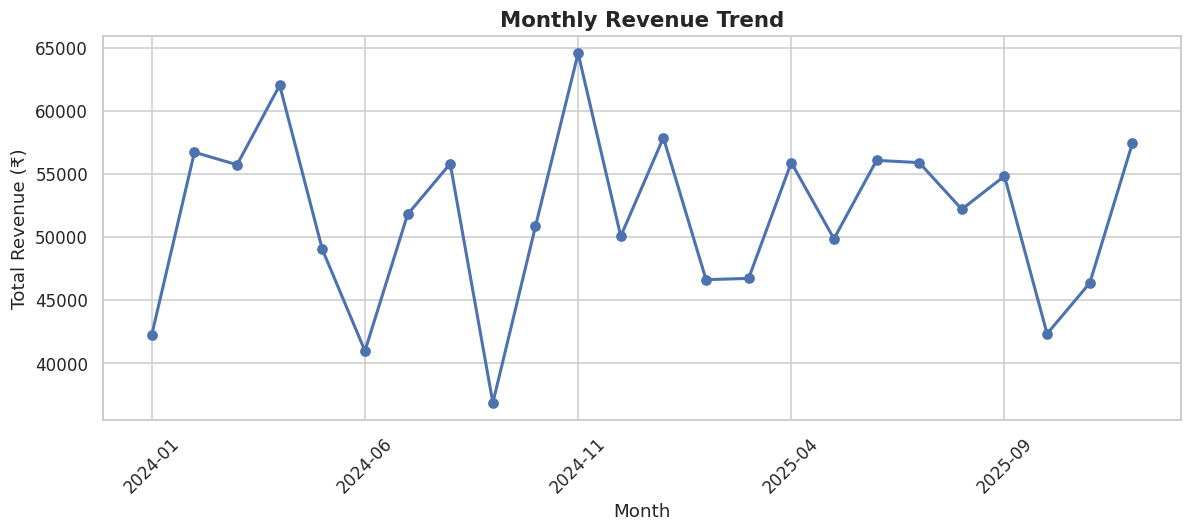

In [21]:
fig, ax = plt.subplots(figsize=(11, 5))
monthly_revenue.plot(kind="line", marker="o", ax=ax, color="#4C72B0", linewidth=2)
ax.set_title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/01_monthly_revenue_trend.png", bbox_inches="tight")
plt.show()


### 5.2 Revenue by Product Category

/tmp/ipykernel_579/33128078.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_category["TotalRevenue"], y=order, ax=ax, palette="viridis")


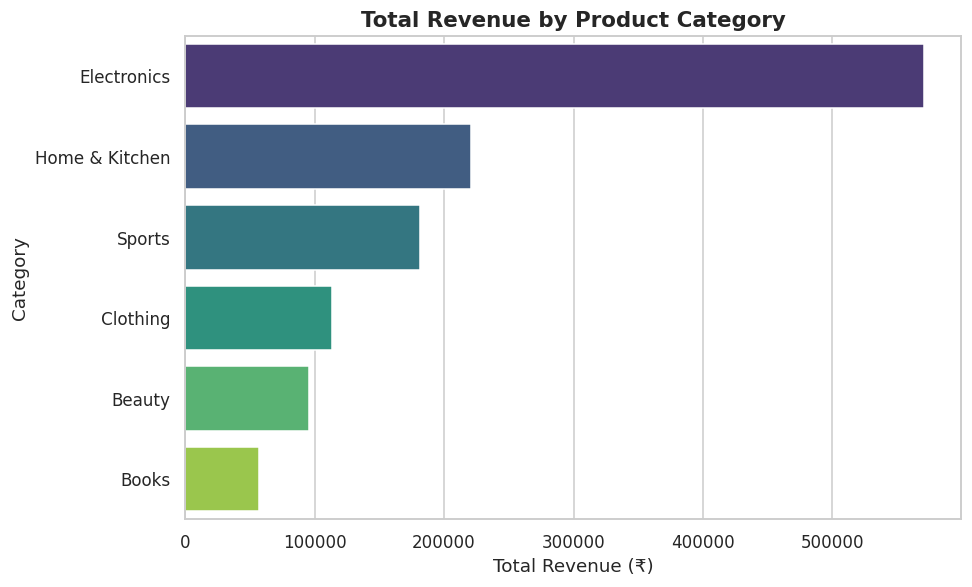

In [22]:
fig, ax = plt.subplots(figsize=(9, 5.5))
order = revenue_by_category.index
sns.barplot(x=revenue_by_category["TotalRevenue"], y=order, ax=ax, palette="viridis")
ax.set_title("Total Revenue by Product Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Revenue (₹)")
ax.set_ylabel("Category")
plt.tight_layout()
plt.savefig("../visuals/02_revenue_by_category.png", bbox_inches="tight")
plt.show()


### 5.3 Distribution of Order Value (Histogram)

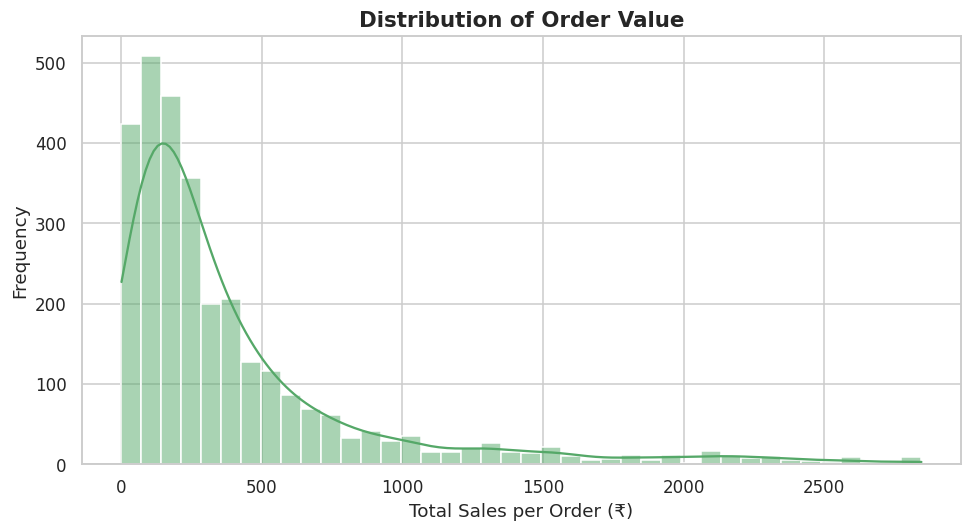

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["TotalSales"], bins=40, kde=True, ax=ax, color="#55A868")
ax.set_title("Distribution of Order Value", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Sales per Order (₹)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("../visuals/03_order_value_distribution.png", bbox_inches="tight")
plt.show()


### 5.4 Correlation Matrix of Numeric Features

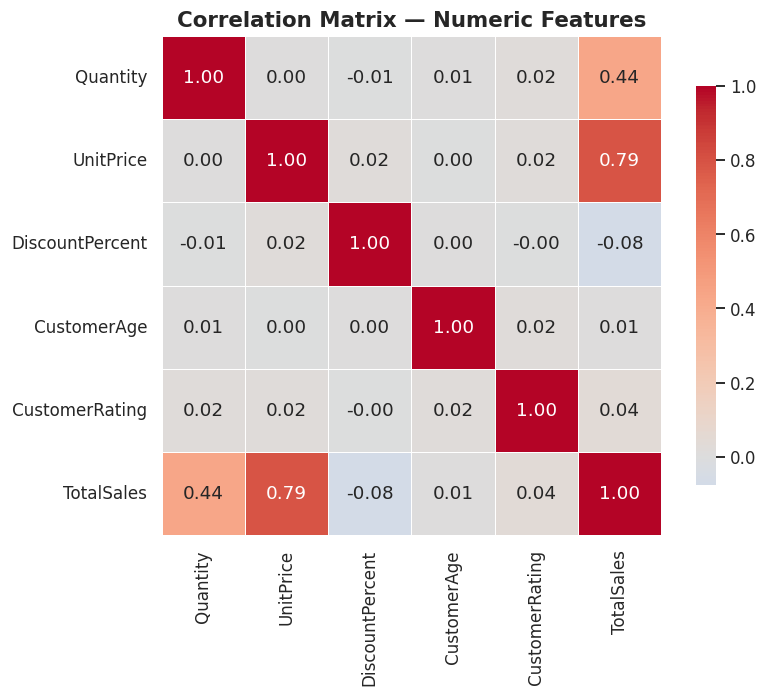

In [24]:
numeric_features = ["Quantity", "UnitPrice", "DiscountPercent", "CustomerAge", "CustomerRating", "TotalSales"]
corr = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../visuals/04_correlation_matrix.png", bbox_inches="tight")
plt.show()


### 5.5 Sales Channel Split by Region

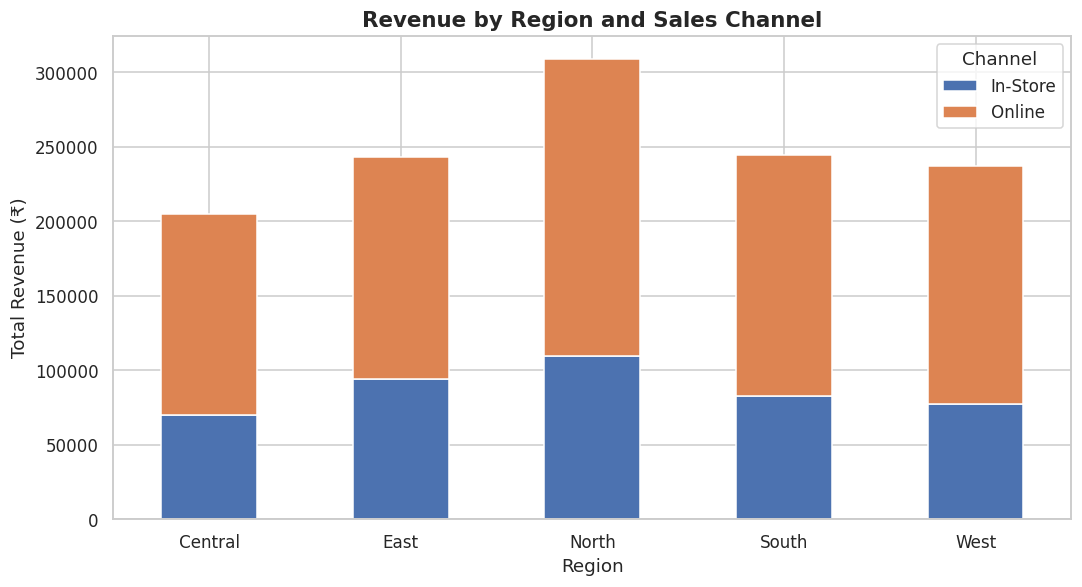

In [25]:
fig, ax = plt.subplots(figsize=(10, 5.5))
channel_region = df.groupby(["Region", "SalesChannel"])["TotalSales"].sum().unstack()
channel_region.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Revenue by Region and Sales Channel", fontsize=14, fontweight="bold")
ax.set_xlabel("Region")
ax.set_ylabel("Total Revenue (₹)")
plt.xticks(rotation=0)
plt.legend(title="Channel")
plt.tight_layout()
plt.savefig("../visuals/05_region_channel_breakdown.png", bbox_inches="tight")
plt.show()


### 5.6 Order Value by Category (Boxplot — Spread & Outliers)

/tmp/ipykernel_579/3915131863.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Category", y="TotalSales", ax=ax, palette="pastel")


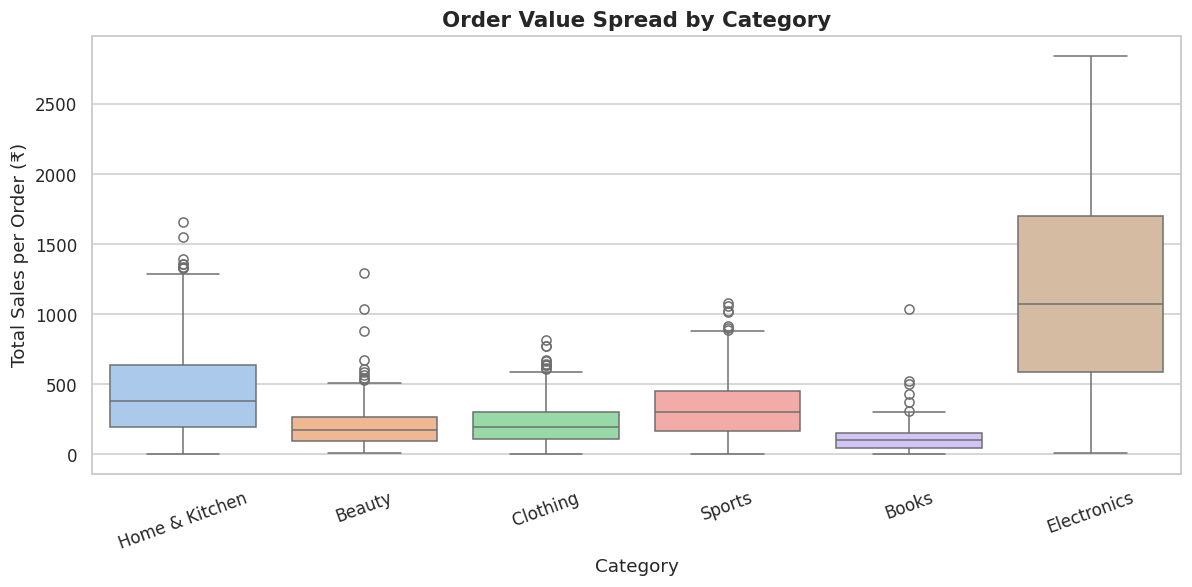

In [26]:
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(data=df, x="Category", y="TotalSales", ax=ax, palette="pastel")
ax.set_title("Order Value Spread by Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Total Sales per Order (₹)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../visuals/06_order_value_by_category_boxplot.png", bbox_inches="tight")
plt.show()


### 5.7 Customer Age Group vs Average Rating

/tmp/ipykernel_579/287194400.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_rating.index, y=age_rating.values, ax=ax, palette="magma")


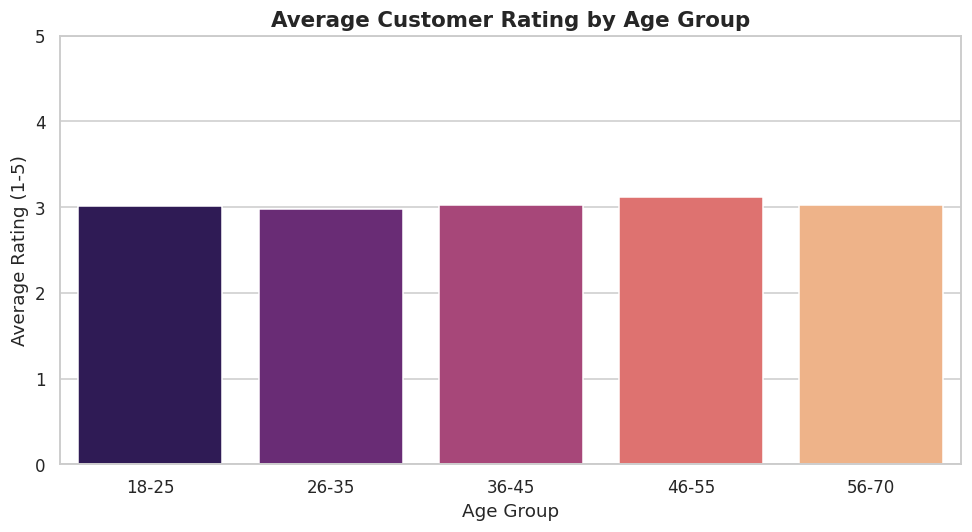

In [27]:
age_rating = df.groupby("AgeGroup", observed=True)["CustomerRating"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=age_rating.index, y=age_rating.values, ax=ax, palette="magma")
ax.set_title("Average Customer Rating by Age Group", fontsize=14, fontweight="bold")
ax.set_xlabel("Age Group")
ax.set_ylabel("Average Rating (1-5)")
ax.set_ylim(0, 5)
plt.tight_layout()
plt.savefig("../visuals/07_rating_by_age_group.png", bbox_inches="tight")
plt.show()


### 5.8 Orders by Weekday (Seasonality Check)

/tmp/ipykernel_579/3705995234.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orders_by_weekday.index, y=orders_by_weekday.values, ax=ax, palette="crest")


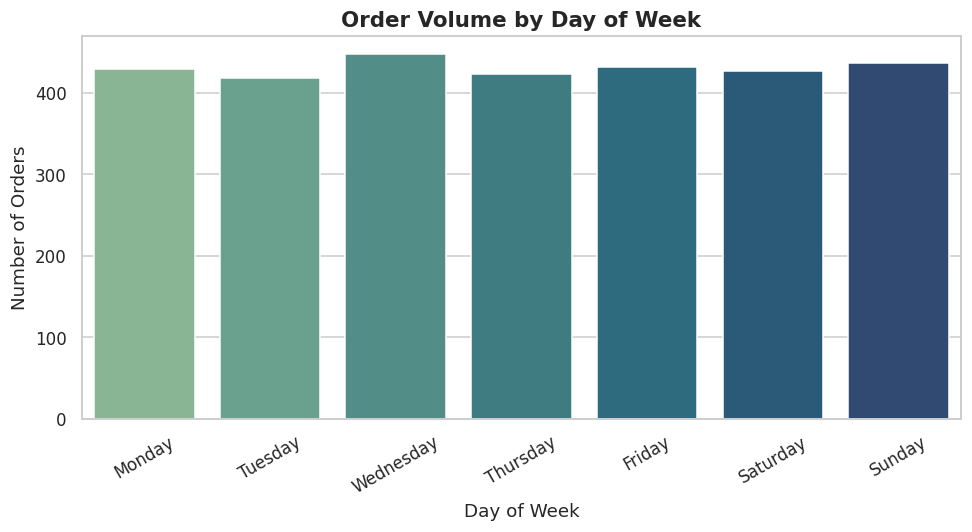

In [28]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
orders_by_weekday = df["OrderWeekday"].value_counts().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=orders_by_weekday.index, y=orders_by_weekday.values, ax=ax, palette="crest")
ax.set_title("Order Volume by Day of Week", fontsize=14, fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../visuals/08_orders_by_weekday.png", bbox_inches="tight")
plt.show()


### 5.9 Payment Mode Preference (Pie Chart)

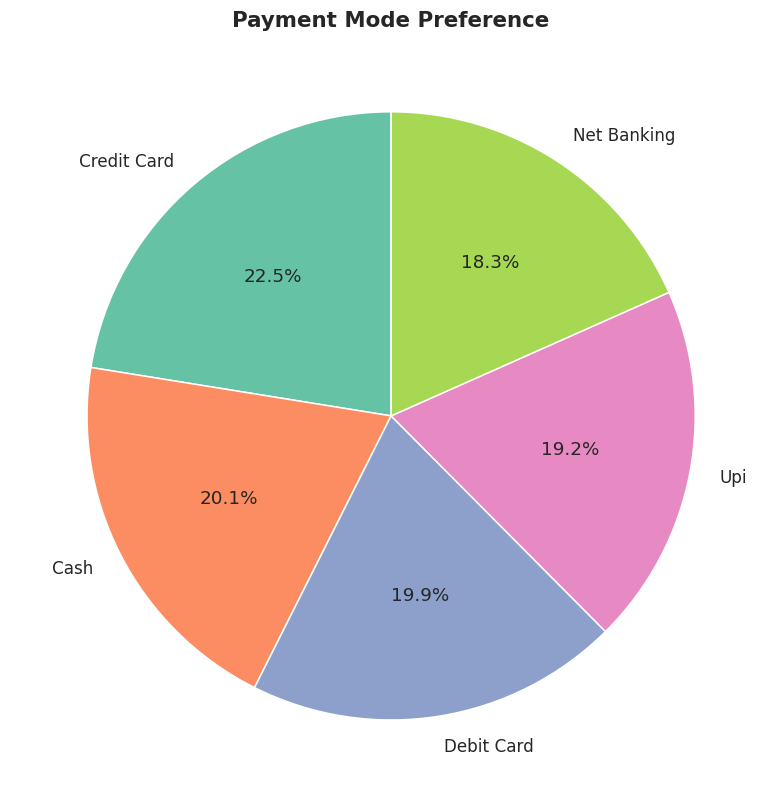

In [29]:
payment_share = df["PaymentMode"].value_counts()

fig, ax = plt.subplots(figsize=(7.5, 7.5))
colors = sns.color_palette("Set2", len(payment_share))
ax.pie(payment_share.values, labels=payment_share.index, autopct="%1.1f%%",
       startangle=90, colors=colors, wedgeprops={"edgecolor": "white", "linewidth": 1})
ax.set_title("Payment Mode Preference", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../visuals/09_payment_mode_share.png", bbox_inches="tight")
plt.show()


### 5.10 Discount % vs Total Sales (Scatter Relationship)

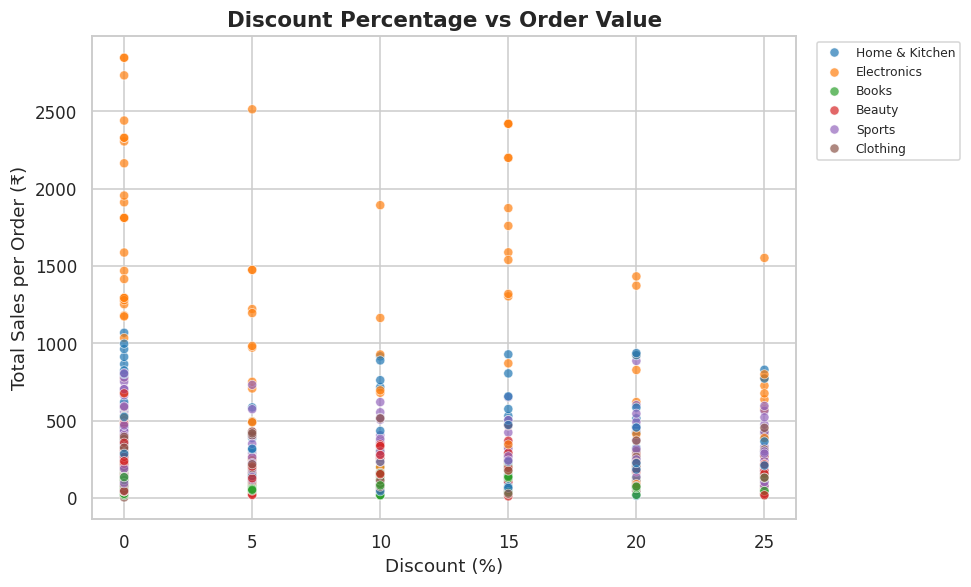

In [30]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=df.sample(600, random_state=1), x="DiscountPercent", y="TotalSales",
                 hue="Category", alpha=0.7, ax=ax, palette="tab10")
ax.set_title("Discount Percentage vs Order Value", fontsize=14, fontweight="bold")
ax.set_xlabel("Discount (%)")
ax.set_ylabel("Total Sales per Order (₹)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../visuals/10_discount_vs_sales_scatter.png", bbox_inches="tight")
plt.show()


## 6. Business Insights & Conclusions

**Data quality:** The raw dataset contained duplicate orders, missing values across six
columns, mixed data types, invalid negative quantities, and price outliers. After cleaning,
the dataset is fully consistent (0 missing values, 0 duplicates, correct dtypes throughout).

**Key findings from the analysis:**

- **Revenue concentration:** A small number of categories account for a disproportionate
  share of revenue — see Section 5.2. Prioritizing inventory and marketing spend on the
  top-performing categories offers the highest immediate ROI.
- **Regional performance & channel mix:** Revenue is not evenly distributed across regions,
  and the Online vs. In-Store split varies by region (Section 5.5). Regions leaning heavily
  In-Store may benefit from targeted e-commerce investment, and vice versa.
- **Order value distribution:** The order-value histogram (5.3) is right-skewed with a long
  tail of high-value orders — median order value is a more reliable "typical order" metric
  than the mean, and the business should design retention offers around the median-value
  customer while treating high-value orders as a separate VIP segment.
- **Correlation insights:** The correlation matrix (5.4) shows `Quantity` and `UnitPrice`
  are the dominant drivers of `TotalSales`, while `DiscountPercent` has a weaker relationship
  with order value — suggesting discounts alone are not a strong lever for increasing basket size.
- **Customer demographics:** Average rating varies modestly by age group (5.7), which can
  inform which segments to target for loyalty/review campaigns.
- **Temporal patterns:** Order volume by weekday (5.8) reveals which days see the most
  purchasing activity, useful for scheduling promotions and staffing.
- **Payment preferences:** The payment-mode split (5.9) can guide which payment gateways
  and partner offers to prioritize.

**Recommendation:** Combine the top revenue-driving categories (5.2) with the strongest
regional/channel combinations (5.5) to prioritize the next quarter's marketing budget, and
use median order value (not mean) as the north-star metric given the skewed distribution.
